# MULTI-TASK MODELS: M1, M2, M3, M4
## Context-Aware Facial Behavior Analysis
### Shared CNN Backbone → Expression + Age + Gender + Suspiciousness Score

## 1. IMPORTS

In [21]:
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Flatten, Dense,
                                      Dropout, BatchNormalization, Activation, Concatenate,
                                      GlobalAveragePooling2D)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

to_categorical = tf.keras.utils.to_categorical

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")


TensorFlow Version: 2.16.1
GPU Available: []


## 2. EXTRACT & LOAD DATA

In [22]:
# ── UTKFace ──────────────────────────────────────────────────────────────────
utk_zip     = './data/UTKFace/utkface-new.zip'
utk_extract = './data/UTKFace/extracted'

if not os.path.exists(utk_extract) or len(os.listdir(utk_extract)) == 0:
    print('Extracting UTKFace...')
    with zipfile.ZipFile(utk_zip, 'r') as z:
        z.extractall(utk_extract)
    print('Done!')
else:
    print('UTKFace already extracted.')

# Prefer the largest available folder of jpg images (UTKFace has 23,708 vs crop_part1 has 9,780)
utk_folder  = utk_extract
best_count  = 0
for root, dirs, files in os.walk(utk_extract):
    jpg_count = sum(1 for f in files if f.endswith('.jpg'))
    if jpg_count > best_count:
        best_count = jpg_count
        utk_folder = root

print(f'UTKFace folder : {utk_folder}')
print(f'Total UTK files: {best_count}')

# ── FER2013 ───────────────────────────────────────────────────────────────────
fer_base        = './data/FER2013/fer2013'
emotion_labels  = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']
emotion_folders = ['angry','disgust','fear','happy','sad','surprise','neutral']
print(f'FER2013 base: {fer_base}')


UTKFace already extracted.
UTKFace folder : ./data/UTKFace/extracted\UTKFace
Total UTK files: 23708
FER2013 base: ./data/FER2013/fer2013


## 3. PREPROCESSING

In [23]:

TARGET_SIZE = (96, 96)   # 224->96: 5x less RAM, 5x faster, less blur on 48x48 FER images
AGE_MAX     = 116.0      # UTKFace max labeled age; normalizes to [0, 1]; multiply back at inference/eval

def load_fer_data(fer_base, emotion_folders, target_size=TARGET_SIZE, total_samples=5000):
    """
    Load FER2013 images.
    FER images are grayscale (48x48). CLAHE is applied for contrast enhancement
    before converting to 3-channel so the backbone sees crisp input
    instead of flat blurry upscales.
    """
    samples_per_class_per_split = total_samples // (len(emotion_folders) * 2)
    images, emotions = [], []
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))

    for split in ["train", "test"]:
        for eidx, folder in enumerate(emotion_folders):
            path  = os.path.join(fer_base, split, folder)
            files = [f for f in os.listdir(path) if f.lower().endswith((".jpg", ".png"))]
            np.random.shuffle(files)
            files = files[:samples_per_class_per_split]
            for fname in files:
                img = cv2.imread(os.path.join(path, fname))
                if img is None: continue
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                gray = clahe.apply(gray)
                img3 = cv2.merge([gray, gray, gray])
                img3 = cv2.resize(img3, target_size).astype(np.float32) / 255.0
                images.append(img3)
                emotions.append(eidx)

    images   = np.array(images,   dtype=np.float32)
    emotions = np.array(emotions, dtype=np.int32)
    print(f"  Total loaded: {len(images)} | ~{samples_per_class_per_split} per class per split")
    return images, emotions


def load_utk_data(utk_folder, target_size=TARGET_SIZE, max_samples=12000):
    """
    Load UTKFace images (color RGB) with age-balanced sampling.
    Ages are normalized to [0, 1] by dividing by AGE_MAX (80.0).
    Multiply by AGE_MAX at inference/evaluation to get years.
    """
    AGE_BINS  = [(0, 12), (13, 17), (18, 35), (36, 59), (60, 150)]
    n_bins    = len(AGE_BINS)
    per_bin   = max_samples // n_bins

    all_files = [f for f in os.listdir(utk_folder) if f.lower().endswith(".jpg")]
    binned = {i: [] for i in range(n_bins)}
    for fname in all_files:
        try:
            parts  = fname.split("_")
            age    = int(parts[0])
            gender = int(parts[1])
            if gender not in [0, 1]: continue
        except:
            continue
        for i, (lo, hi) in enumerate(AGE_BINS):
            if lo <= age <= hi:
                binned[i].append(fname)
                break

    images, ages, genders = [], [], []
    for i, (lo, hi) in enumerate(AGE_BINS):
        bucket = binned[i]
        np.random.shuffle(bucket)
        bucket = bucket[:per_bin]
        print(f"  Age {lo:>3}-{hi:<3}: {len(bucket):>4} samples (available: {len(binned[i])})")
        for fname in bucket:
            try:
                parts  = fname.split("_")
                age    = int(parts[0])
                gender = int(parts[1])
            except:
                continue
            img = cv2.imread(os.path.join(utk_folder, fname))
            if img is None: continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, target_size).astype(np.float32) / 255.0
            images.append(img)
            ages.append(age)
            genders.append(gender)

    ages_normalized = np.array(ages, dtype=np.float32) / AGE_MAX   # normalize to [0, 1]
    return (np.array(images,  dtype=np.float32),
            ages_normalized,
            np.array(genders, dtype=np.int32))


print("Loading FER2013...")
fer_images, fer_emotions = load_fer_data(fer_base, emotion_folders, total_samples=22000)
print(f"FER2013 shape : {fer_images.shape}")

print("Loading UTKFace...")
utk_images, utk_ages, utk_genders = load_utk_data(utk_folder, max_samples=20000)
print(f"UTKFace shape : {utk_images.shape}")
print(f"Age range (normalized): [{utk_ages.min():.3f}, {utk_ages.max():.3f}]  (x{AGE_MAX:.0f} = years)")

fer_mb = fer_images.nbytes / 1e6
utk_mb = utk_images.nbytes / 1e6
print(f"\nMemory \u2014 FER: {fer_mb:.0f} MB  |  UTK: {utk_mb:.0f} MB  |  Total: {fer_mb+utk_mb:.0f} MB")


Loading FER2013...
  Total loaded: 16837 | ~1571 per class per split
FER2013 shape : (16837, 96, 96, 3)
Loading UTKFace...
  Age   0-12 : 3413 samples (available: 3413)
  Age  13-17 :  820 samples (available: 820)
  Age  18-35 : 4000 samples (available: 10874)
  Age  36-59 : 4000 samples (available: 5911)
  Age  60-150: 2690 samples (available: 2690)
UTKFace shape : (14923, 96, 96, 3)
Age range (normalized): [0.009, 1.000]  (x116 = years)

Memory — FER: 1862 MB  |  UTK: 1650 MB  |  Total: 3512 MB


In [24]:
# -- FER split 70/15/15 ----------------------------------------------------
fer_emo_cat = to_categorical(fer_emotions, num_classes=7)

X_fer_train, X_fer_tmp, y_fer_train, y_fer_tmp = train_test_split(
    fer_images, fer_emo_cat, test_size=0.30, random_state=42, stratify=fer_emotions)
X_fer_val, X_fer_test, y_fer_val, y_fer_test = train_test_split(
    X_fer_tmp, y_fer_tmp, test_size=0.50, random_state=42)

# -- UTK split 70/15/15 -----------------------------------------------------
X_utk_train, X_utk_tmp, ya_train, ya_tmp, yg_train, yg_tmp = train_test_split(
    utk_images, utk_ages, utk_genders, test_size=0.30, random_state=42)
X_utk_val, X_utk_test, ya_val, ya_test, yg_val, yg_test = train_test_split(
    X_utk_tmp, ya_tmp, yg_tmp, test_size=0.50, random_state=42)

print(f"FER  - Train: {X_fer_train.shape}, Val: {X_fer_val.shape}, Test: {X_fer_test.shape}")
print(f"UTK  - Train: {X_utk_train.shape}, Val: {X_utk_val.shape}, Test: {X_utk_test.shape}")

# -- Expression class weights (combats FER2013 class imbalance) ---------------
emotion_labels_int = np.argmax(y_fer_train, axis=1)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(emotion_labels_int),
    y=emotion_labels_int
)
expr_class_weight_dict = dict(enumerate(class_weights_array))
print(f"\nExpression class weights:")
emotion_names = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]
for i, name in enumerate(emotion_names):
    print(f"  {name:>10}: {expr_class_weight_dict[i]:.4f}")

# Per-sample class weights for FER training data (used in M4 sample_weights)
fer_expr_sample_weights = np.array([expr_class_weight_dict[c] for c in emotion_labels_int],
                                    dtype=np.float32)
print(f"FER expr sample weights range: [{fer_expr_sample_weights.min():.3f}, {fer_expr_sample_weights.max():.3f}]")


FER  - Train: (11785, 96, 96, 3), Val: (2526, 96, 96, 3), Test: (2526, 96, 96, 3)
UTK  - Train: (10446, 96, 96, 3), Val: (2238, 96, 96, 3), Test: (2239, 96, 96, 3)

Expression class weights:
       Angry: 0.9512
     Disgust: 4.3957
        Fear: 0.9271
       Happy: 0.7656
         Sad: 0.8533
    Surprise: 1.0015
     Neutral: 0.8577
FER expr sample weights range: [0.766, 4.396]


Suspicion pseudo-labels generated.
  FER  train | mean=0.309  std=0.227  |  suspicious(>0.5): 18.3%
  UTK  train | mean=0.098  std=0.008  |  suspicious(>0.5): 0.0%


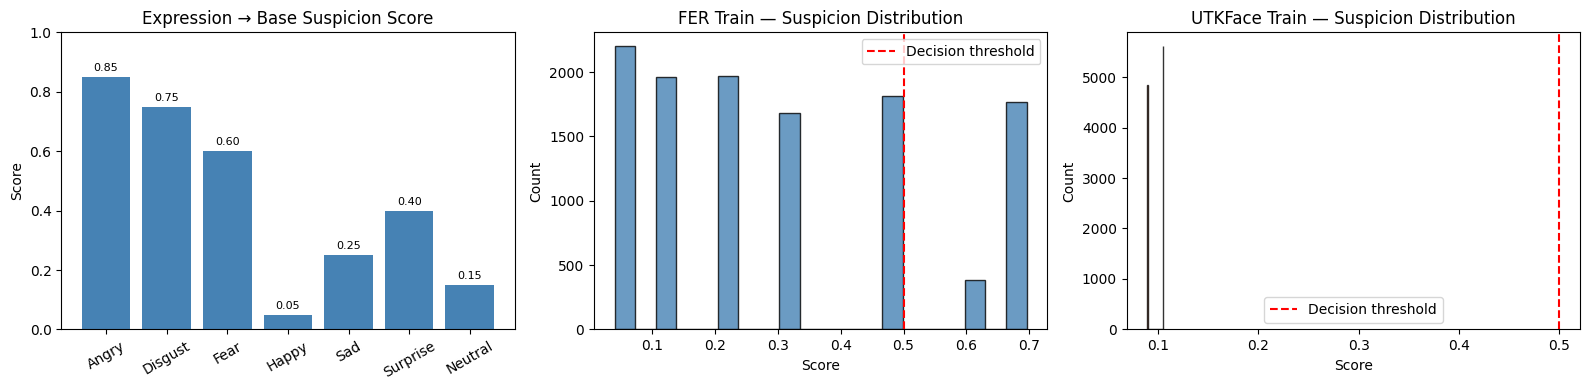

In [25]:

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║        SECTION: RULE-BASED SUSPICION PSEUDO-LABEL GENERATION               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# Since no labeled "suspicious" dataset exists, we use a domain-expert rule
# function to generate continuous pseudo-labels in [0, 1] from the ground-truth
# expression / age / gender labels that ARE available.
#
# Design rationale:
#   • Expression is the PRIMARY driver (high weight) — behavioral signal
#   • Age and gender are MODIFIERS (secondary) — contextual amplifiers
#   • Scores are multiplicative so that neutral expression stays low regardless
#     of demographics, and high-suspicion expressions are further amplified by
#     demographic context.
#
# Label source reliability → sample weights used during training:
#   FER images  → expression known, demographics inferred → sw_susp = 1.0
#   UTK images  → demographics known, expression inferred → sw_susp = 0.5

# ── Expression base suspicion scores ─────────────────────────────────────────
# Index: 0=Angry 1=Disgust 2=Fear 3=Happy 4=Sad 5=Surprise 6=Neutral
EXPR_SUSP_SCORES = {
    0: 0.85,   # Angry    → strong threat indicator
    1: 0.75,   # Disgust  → hostility / contempt signal
    2: 0.60,   # Fear     → stress indicator (victim OR perpetrator context)
    3: 0.05,   # Happy    → minimal threat
    4: 0.25,   # Sad      → low-moderate
    5: 0.40,   # Surprise → ambiguous; can accompany alarm
    6: 0.15,   # Neutral  → low baseline
}

def _age_factor(age):
    """Behavioural-risk modifier by age group (literature-informed)."""
    age = float(age)
    if   age < 13:  return 0.30   # child — low risk
    elif age < 18:  return 0.65   # adolescent — elevated
    elif age < 36:  return 1.00   # young adult — peak reference
    elif age < 60:  return 0.75   # adult
    else:           return 0.35   # senior — low risk

def _gender_factor(gender):
    """Marginal modifier: 0 = Male, 1 = Female."""
    return 1.00 if int(gender) == 0 else 0.85

def rule_based_suspicion(emotion_idx=None, age=None, gender=None):
    """
    Compute a suspicion pseudo-label in [0, 1].
    Any argument can be None → population-average default is used.

    Examples:
        rule_based_suspicion(emotion_idx=0)                  # Angry, avg demo
        rule_based_suspicion(emotion_idx=0, age=25, gender=0)  # Angry young male
        rule_based_suspicion(age=22, gender=0)               # young male, avg expr
    """
    e = EXPR_SUSP_SCORES[int(emotion_idx)] if emotion_idx is not None else 0.35  # population avg
    a = _age_factor(age)                    if age        is not None else 0.88  # avg young adult
    g = _gender_factor(gender)              if gender     is not None else 0.93  # avg gender
    return float(np.clip(e * a * g, 0.0, 1.0))

# ── Generate pseudo-labels ────────────────────────────────────────────────────
# FER: expression label known → expression-driven score (demographics at avg)
susp_fer_train = np.array([rule_based_suspicion(emotion_idx=np.argmax(y)) for y in y_fer_train])
susp_fer_val   = np.array([rule_based_suspicion(emotion_idx=np.argmax(y)) for y in y_fer_val])
susp_fer_test  = np.array([rule_based_suspicion(emotion_idx=np.argmax(y)) for y in y_fer_test])

# UTK: age + gender known → demographic-driven score (expression at population avg)
susp_utk_train = np.array([rule_based_suspicion(age=ya_train[i], gender=yg_train[i])
                            for i in range(len(ya_train))])
susp_utk_val   = np.array([rule_based_suspicion(age=ya_val[i],   gender=yg_val[i])
                            for i in range(len(ya_val))])
susp_utk_test  = np.array([rule_based_suspicion(age=ya_test[i],  gender=yg_test[i])
                            for i in range(len(ya_test))])

print('Suspicion pseudo-labels generated.')
print(f'  FER  train | mean={susp_fer_train.mean():.3f}  std={susp_fer_train.std():.3f}'
      f'  |  suspicious(>0.5): {(susp_fer_train > 0.5).mean()*100:.1f}%')
print(f'  UTK  train | mean={susp_utk_train.mean():.3f}  std={susp_utk_train.std():.3f}'
      f'  |  suspicious(>0.5): {(susp_utk_train > 0.5).mean()*100:.1f}%')

# ── Visualise the rule to sanity-check it ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) Per-emotion base scores
expr_base = [EXPR_SUSP_SCORES[i] for i in range(7)]
axes[0].bar(emotion_labels, expr_base, color='steelblue')
axes[0].set_title('Expression → Base Suspicion Score')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(expr_base):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)

# 2) FER train suspicion distribution
axes[1].hist(susp_fer_train, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(0.5, color='red', linestyle='--', label='Decision threshold')
axes[1].set_title('FER Train — Suspicion Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Count')
axes[1].legend()

# 3) UTK train suspicion distribution
axes[2].hist(susp_utk_train, bins=30, color='coral', edgecolor='black', alpha=0.8)
axes[2].axvline(0.5, color='red', linestyle='--', label='Decision threshold')
axes[2].set_title('UTKFace Train — Suspicion Distribution')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()


## 4. SHARED CNN BACKBONE

In [26]:

def build_shared_backbone(input_shape=None):
    """
    Shared backbone using MobileNetV2 pretrained on ImageNet.
    - First 100 layers frozen (detect generic edges/textures -- already optimal).
    - Top layers trainable for fine-tuning on facial data.
    - Output: (batch, 1280) feature vector via global average pooling.
    """
    if input_shape is None:
        input_shape = (*TARGET_SIZE, 3)
    inputs = Input(shape=input_shape, name="image_input")

    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,      # remove ImageNet classifier head
        weights="imagenet",     # pretrained on 1.2M ImageNet images
        pooling="avg"           # global average pool -> (batch, 1280)
    )

    # Freeze early layers (generic visual features -- edges, textures, corners)
    for layer in base.layers[:100]:
        layer.trainable = False
    # Fine-tune top layers (high-level facial features -- eyes, mouth, skin)
    for layer in base.layers[100:]:
        layer.trainable = True

    x = base(inputs)
    x = Dropout(0.3)(x)
    return inputs, x


print(f"Shared backbone (MobileNetV2 pretrained) defined.")
print(f"Input shape : {(*TARGET_SIZE, 3)}")
print(f"Output shape: (batch, 1280)  -- ImageNet pretrained feature vector")


Shared backbone (MobileNetV2 pretrained) defined.
Input shape : (96, 96, 3)
Output shape: (batch, 1280)  -- ImageNet pretrained feature vector


## 5. BUILD M1 — Expression Only

In [27]:

def build_m1(input_shape=None):
    if input_shape is None:
        input_shape = (*TARGET_SIZE, 3)
    inputs, x = build_shared_backbone(input_shape)

    # Expression head (deepened for 7-class)
    fe = Dense(256, activation='relu', name='expr_fc1')(x)
    fe = BatchNormalization()(fe)
    fe = Dropout(0.4)(fe)
    fe = Dense(128, activation='relu', name='expr_fc2')(fe)
    fe = Dropout(0.3)(fe)
    expr_out = Dense(7, activation='softmax', name='expression_out')(fe)

    susp = Dense(64, activation='relu')(fe)
    susp_out = Dense(1, activation='sigmoid', name='suspiciousness_out')(susp)

    return Model(inputs=inputs, outputs=[expr_out, susp_out], name='M1_Expression_Only')

M1 = build_m1()
M1.summary()


Model: "M1_Expression_Only"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 1280)      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expr_fc1 (Dense)    │ (None, 256)       │    327,936 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ expr_fc1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expr_fc2 (Dense)    │ (None, 128)       │     32,896 │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 128)       │          0 │ expr_fc2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expression_out      │ (None, 7)         │        903 │ dropout_18[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ suspiciousness_out  │ (None, 1)         │         65 │ dense_4[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,629,064 (10.03 MB)

 Trainable params: 2,232,008 (8.51 MB)

 Non-trainable params: 397,056 (1.51 MB)

## 6. BUILD M2 — Expression + Gender

In [28]:

def build_m2(input_shape=None):
    if input_shape is None:
        input_shape = (*TARGET_SIZE, 3)
    inputs, x = build_shared_backbone(input_shape)

    # Expression head (deepened for 7-class)
    fe = Dense(256, activation='relu', name='expr_fc1')(x)
    fe = BatchNormalization()(fe)
    fe = Dropout(0.4)(fe)
    fe = Dense(128, activation='relu', name='expr_fc2')(fe)
    fe = Dropout(0.3)(fe)
    expr_out = Dense(7, activation='softmax', name='expression_out')(fe)

    fg = Dense(64, activation='relu', name='gender_features')(x)
    fg = Dropout(0.2)(fg)
    gender_out = Dense(1, activation='sigmoid', name='gender_out')(fg)

    fused = Concatenate(name='fusion')([fe, fg])
    susp  = Dense(64, activation='relu')(fused)
    susp_out = Dense(1, activation='sigmoid', name='suspiciousness_out')(susp)

    return Model(inputs=inputs, outputs=[expr_out, gender_out, susp_out], name='M2_Expr_Gender')

M2 = build_m2()
M2.summary()


Model: "M2_Expr_Gender"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 1280)      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expr_fc1 (Dense)    │ (None, 256)       │    327,936 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ expr_fc1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expr_fc2 (Dense)    │ (None, 128)       │     32,896 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_features     │ (None, 64)        │     81,984 │ dropout_19[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 128)       │          0 │ expr_fc2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 64)        │          0 │ gender_features[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 192)       │          0 │ dropout_21[0][0], │
│ (Concatenate)       │                   │            │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     12,352 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expression_out      │ (None, 7)         │        903 │ dropout_21[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_out (Dense)  │ (None, 1)         │         65 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ suspiciousness_out  │ (None, 1)         │         65 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,715,209 (10.36 MB)

 Trainable params: 2,318,153 (8.84 MB)

 Non-trainable params: 397,056 (1.51 MB)

## 7. BUILD M3 — Expression + Age

In [29]:

def build_m3(input_shape=None):
    if input_shape is None:
        input_shape = (*TARGET_SIZE, 3)
    inputs, x = build_shared_backbone(input_shape)

    # Expression head (deepened for 7-class)
    fe = Dense(256, activation='relu', name='expr_fc1')(x)
    fe = BatchNormalization()(fe)
    fe = Dropout(0.4)(fe)
    fe = Dense(128, activation='relu', name='expr_fc2')(fe)
    fe = Dropout(0.3)(fe)
    expr_out = Dense(7, activation='softmax', name='expression_out')(fe)

    # Age head (sigmoid: age normalized to [0, 1])
    fa = Dense(64, activation='relu', name='age_features')(x)
    fa = Dropout(0.2)(fa)
    age_out = Dense(1, activation='sigmoid', name='age_out')(fa)

    fused = Concatenate(name='fusion')([fe, fa])
    susp  = Dense(64, activation='relu')(fused)
    susp_out = Dense(1, activation='sigmoid', name='suspiciousness_out')(susp)

    return Model(inputs=inputs, outputs=[expr_out, age_out, susp_out], name='M3_Expr_Age')

M3 = build_m3()
M3.summary()


Model: "M3_Expr_Age"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 1280)      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expr_fc1 (Dense)    │ (None, 256)       │    327,936 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ expr_fc1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expr_fc2 (Dense)    │ (None, 128)       │     32,896 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_features        │ (None, 64)        │     81,984 │ dropout_23[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 128)       │          0 │ expr_fc2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 64)        │          0 │ age_features[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 192)       │          0 │ dropout_25[0][0], │
│ (Concatenate)       │                   │            │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │     12,352 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expression_out      │ (None, 7)         │        903 │ dropout_25[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_out (Dense)     │ (None, 1)         │         65 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ suspiciousness_out  │ (None, 1)         │         65 │ dense_6[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,715,209 (10.36 MB)

 Trainable params: 2,318,153 (8.84 MB)

 Non-trainable params: 397,056 (1.51 MB)

## 8. BUILD M4 — Expression + Age + Gender (Full Model)

In [30]:

def build_m4(input_shape=None):
    if input_shape is None:
        input_shape = (*TARGET_SIZE, 3)
    inputs, x = build_shared_backbone(input_shape)

    # -- Expression head ------------------------------------------------------
    fe = Dense(256, activation="relu", name="expr_fc1")(x)
    fe = BatchNormalization()(fe)
    fe = Dropout(0.4)(fe)
    fe = Dense(128, activation="relu", name="expr_fc2")(fe)
    fe = Dropout(0.3)(fe)
    expr_out = Dense(7, activation="softmax", name="expression_out")(fe)

    # -- Age head (deeper: 128->64->1 for better age regression) --------------
    fa = Dense(128, activation="relu", name="age_fc1")(x)
    fa = BatchNormalization()(fa)
    fa = Dropout(0.3)(fa)
    fa = Dense(64, activation="relu", name="age_fc2")(fa)
    fa = Dropout(0.2)(fa)
    age_out = Dense(1, activation="sigmoid", name="age_out")(fa)

    # -- Gender head ----------------------------------------------------------
    fg = Dense(64, activation="relu", name="gender_features")(x)
    fg = Dropout(0.2)(fg)
    gender_out = Dense(1, activation="sigmoid", name="gender_out")(fg)

    # -- Suspiciousness head --------------------------------------------------
    fused = Concatenate(name="fusion")([fe, fa, fg])
    susp  = Dense(64, activation="relu")(fused)
    susp_out = Dense(1, activation="sigmoid", name="suspiciousness_out")(susp)

    return Model(inputs=inputs, outputs=[expr_out, age_out, gender_out, susp_out],
                 name="M4_Full_Model")

M4 = build_m4()
M4.summary()


Model: "M4_Full_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 1280)      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expr_fc1 (Dense)    │ (None, 256)       │    327,936 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_fc1 (Dense)     │ (None, 128)       │    163,968 │ dropout_27[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ expr_fc1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ age_fc1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expr_fc2 (Dense)    │ (None, 128)       │     32,896 │ dropout_28[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_fc2 (Dense)     │ (None, 64)        │      8,256 │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_features     │ (None, 64)        │     81,984 │ dropout_27[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 128)       │          0 │ expr_fc2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 64)        │          0 │ age_fc2[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 64)        │          0 │ gender_features[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 256)       │          0 │ dropout_29[0][0], │
│ (Concatenate)       │                   │            │ dropout_31[0][0], │
│                     │                   │            │ dropout_32[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │     16,448 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expression_out      │ (None, 7)         │        903 │ dropout_29[0][0]  │
│ (Dense)             │                   │            │                 

 Total params: 2,892,106 (11.03 MB)

 Trainable params: 2,494,794 (9.52 MB)

 Non-trainable params: 397,312 (1.52 MB)

## 9. DATA AUGMENTATION

In [31]:
class AugmentedDataGenerator:
    def __init__(self, horizontal_flip=True, brightness_range=None, rotation_range=0,
                 zoom_range=0.0, width_shift=0.0, height_shift=0.0):
        self.horizontal_flip  = horizontal_flip
        self.brightness_range = brightness_range
        self.rotation_range   = rotation_range
        self.zoom_range       = zoom_range
        self.width_shift      = width_shift
        self.height_shift     = height_shift

    def _augment(self, image):
        h, w = image.shape[:2]
        img  = image.copy()
        if self.horizontal_flip and np.random.random() > 0.5:
            img = cv2.flip(img, 1)
        if self.rotation_range > 0:
            angle = np.random.uniform(-self.rotation_range, self.rotation_range)
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
            img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
        if self.zoom_range > 0:
            scale = np.random.uniform(1.0 - self.zoom_range, 1.0 + self.zoom_range)
            M = cv2.getRotationMatrix2D((w/2, h/2), 0, scale)
            img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
        if self.width_shift > 0 or self.height_shift > 0:
            tx = np.random.uniform(-self.width_shift * w, self.width_shift * w)
            ty = np.random.uniform(-self.height_shift * h, self.height_shift * h)
            M  = np.float32([[1, 0, tx], [0, 1, ty]])
            img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT_101)
        if self.brightness_range:
            factor = np.random.uniform(*self.brightness_range)
            img = np.clip(img * factor, 0.0, 1.0)
        return img.astype(np.float32)

    def flow(self, X, y, batch_size=32, sample_weights=None):
        """Yields (X_batch, y_batch) or (X_batch, y_batch, sw_batch) if sample_weights given.
        sample_weights: list of arrays, one per output -- 1.0 where label is real, 0.0 where dummy."""
        n = len(X)
        while True:
            idx = np.random.permutation(n)
            for s in range(0, n, batch_size):
                b = idx[s:s+batch_size]
                Xb = np.array([self._augment(X[i]) for i in b])
                yb = tuple(yi[b] for yi in y) if isinstance(y, list) else y[b]
                if sample_weights is not None:
                    swb = tuple(sw[b] for sw in sample_weights)
                    yield Xb, yb, swb
                else:
                    yield Xb, yb

augmentor = AugmentedDataGenerator(
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],   # wider than before [0.8, 1.2]
    rotation_range=15,              # up from 10
    zoom_range=0.15,                # new
    width_shift=0.1,                # new
    height_shift=0.1                # new
)
print("Augmentor ready.")


Augmentor ready.


## 10. CALLBACKS

In [32]:
def get_callbacks(model_name):
    return [
        ModelCheckpoint(f'{model_name}_best.keras', monitor='val_loss',
                        save_best_only=True, mode='min', verbose=1),
        EarlyStopping(monitor='val_loss', patience=15,   # was 10
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5,                    # was 3
                          min_lr=1e-7, verbose=1)
    ]

BATCH_SIZE = 32
EPOCHS     = 80    # was 60 -- more room for convergence
print('Callbacks defined.')


Callbacks defined.


## 11. TRAIN M1

In [33]:

# M1: FER only — expression head + suspicion head
steps_m1 = len(X_fer_train) // BATCH_SIZE

M1_COMPILE = dict(
    loss={
        "expression_out":     "categorical_crossentropy",
        "suspiciousness_out": "binary_crossentropy"
    },
    loss_weights={
        "expression_out":     2.0,
        "suspiciousness_out": 0.5
    },
    metrics={"expression_out": "accuracy"}
)

VAL_M1 = (X_fer_val, [y_fer_val, susp_fer_val])

def make_gen_m1():
    return augmentor.flow(
        X_fer_train,
        [y_fer_train, susp_fer_train],
        sample_weights=[fer_expr_sample_weights, np.ones(len(X_fer_train))],
        batch_size=BATCH_SIZE
    )

# Phase 1: freeze backbone, warm up heads (10 epochs, lr=1e-3)
print("Phase 1: Warming up M1 heads (backbone frozen)...")
for layer in M1.layers:
    if hasattr(layer, "layers"):
        for sublayer in layer.layers:
            sublayer.trainable = False

M1.compile(optimizer=Adam(1e-3), **M1_COMPILE)
M1.fit(make_gen_m1(), steps_per_epoch=steps_m1,
       validation_data=VAL_M1, epochs=10, verbose=1)
print("Phase 1 complete.")

# Phase 2: unfreeze top backbone layers, fine-tune (60 epochs, lr=1e-4)
print("\nPhase 2: Fine-tuning M1...")
for layer in M1.layers:
    if hasattr(layer, "layers"):
        for i, sublayer in enumerate(layer.layers):
            sublayer.trainable = (i >= 100)
    else:
        layer.trainable = True

M1.compile(optimizer=Adam(1e-4), **M1_COMPILE)
print("Training M1...")
hist_m1 = M1.fit(
    make_gen_m1(),
    steps_per_epoch=steps_m1,
    validation_data=VAL_M1,
    epochs=EPOCHS,
    callbacks=get_callbacks("M1"),
    verbose=1
)
print("M1 training complete!")


Phase 1: Warming up M1 heads (backbone frozen)...
Epoch 1/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 66s 164ms/step - expression_out_accuracy: 0.2338 - expression_out_loss: 2.1194 - loss: 4.5599 - suspiciousness_out_loss: 0.6424 - val_expression_out_accuracy: 0.3504 - val_expression_out_loss: 1.6904 - val_loss: 3.6857 - val_suspiciousness_out_loss: 0.6102
Epoch 2/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 51s 139ms/step - expression_out_accuracy: 0.2834 - expression_out_loss: 1.8100 - loss: 3.9327 - suspiciousness_out_loss: 0.6208 - val_expression_out_accuracy: 0.3531 - val_expression_out_loss: 1.6638 - val_loss: 3.6316 - val_suspiciousness_out_loss: 0.6083
Epoch 3/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 49s 134ms/step - expression_out_accuracy: 0.3060 - expression_out_loss: 1.7527 - loss: 3.8102 - suspiciousness_out_loss: 0.6136 - val_expression_out_accuracy: 0.3325 - val_expression_out_loss: 1.6833 - val_loss: 3.6731 - val_suspiciousness_out_loss: 0.6134
Epoch 4/10
368/368 ━━━━━━━━━━━━━━━━━━━━ 51s 137ms/step - ex

## 12. TRAIN M2

In [34]:

# M2: FER (expression) + UTK (gender)
n_fer = len(X_fer_train)
n_utk = len(X_utk_train)

X_m2_train  = np.concatenate([X_fer_train, X_utk_train],                        axis=0)
ye_m2_train = np.concatenate([y_fer_train, np.zeros((n_utk, 7))],               axis=0)
yg_m2_train = np.concatenate([np.zeros(n_fer), yg_train.astype(np.float32)],    axis=0)
ys_m2_train = np.concatenate([susp_fer_train,  susp_utk_train],                 axis=0)

sw_expr_m2_train   = np.concatenate([fer_expr_sample_weights, np.zeros(n_utk)])
sw_gender_m2_train = np.concatenate([np.zeros(n_fer),         np.ones(n_utk)])
sw_susp_m2_train   = np.concatenate([np.ones(n_fer),          0.5 * np.ones(n_utk)])

X_m2_val  = np.concatenate([X_fer_val, X_utk_val],                                   axis=0)
ye_m2_val = np.concatenate([y_fer_val, np.zeros((len(X_utk_val), 7))],               axis=0)
yg_m2_val = np.concatenate([np.zeros(len(X_fer_val)), yg_val.astype(np.float32)],    axis=0)
ys_m2_val = np.concatenate([susp_fer_val,              susp_utk_val],                axis=0)

sw_expr_m2_val   = np.concatenate([np.ones(len(X_fer_val)),   np.zeros(len(X_utk_val))])
sw_gender_m2_val = np.concatenate([np.zeros(len(X_fer_val)),  np.ones(len(X_utk_val))])
sw_susp_m2_val   = np.concatenate([np.ones(len(X_fer_val)),   0.5 * np.ones(len(X_utk_val))])

steps_m2 = len(X_m2_train) // BATCH_SIZE

M2_COMPILE = dict(
    loss={
        "expression_out":     "categorical_crossentropy",
        "gender_out":         "binary_crossentropy",
        "suspiciousness_out": "binary_crossentropy"
    },
    loss_weights={
        "expression_out":     2.0,
        "gender_out":         1.0,
        "suspiciousness_out": 0.5
    },
    metrics={"expression_out": "accuracy", "gender_out": "accuracy"}
)

VAL_M2 = (X_m2_val, [ye_m2_val, yg_m2_val, ys_m2_val],
          [sw_expr_m2_val, sw_gender_m2_val, sw_susp_m2_val])

def make_gen_m2():
    return augmentor.flow(
        X_m2_train, [ye_m2_train, yg_m2_train, ys_m2_train],
        sample_weights=[sw_expr_m2_train, sw_gender_m2_train, sw_susp_m2_train],
        batch_size=BATCH_SIZE
    )

# Phase 1: freeze backbone, warm up heads (10 epochs, lr=1e-3)
print("Phase 1: Warming up M2 heads (backbone frozen)...")
for layer in M2.layers:
    if hasattr(layer, "layers"):
        for sublayer in layer.layers:
            sublayer.trainable = False

M2.compile(optimizer=Adam(1e-3), **M2_COMPILE)
M2.fit(make_gen_m2(), steps_per_epoch=steps_m2,
       validation_data=VAL_M2, epochs=10, verbose=1)
print("Phase 1 complete.")

# Phase 2: unfreeze top backbone layers, fine-tune (60 epochs, lr=1e-4)
print("\nPhase 2: Fine-tuning M2...")
for layer in M2.layers:
    if hasattr(layer, "layers"):
        for i, sublayer in enumerate(layer.layers):
            sublayer.trainable = (i >= 100)
    else:
        layer.trainable = True

M2.compile(optimizer=Adam(1e-4), **M2_COMPILE)
print("Training M2...")
hist_m2 = M2.fit(
    make_gen_m2(),
    steps_per_epoch=steps_m2,
    validation_data=VAL_M2,
    epochs=EPOCHS,
    callbacks=get_callbacks("M2"),
    verbose=1
)
print("M2 training complete!")


Phase 1: Warming up M2 heads (backbone frozen)...
Epoch 1/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 113s 152ms/step - expression_out_accuracy: 0.1939 - expression_out_loss: 1.0506 - gender_out_accuracy: 0.5775 - gender_out_loss: 0.2799 - loss: 2.5890 - suspiciousness_out_loss: 0.4155 - val_expression_out_accuracy: 0.2855 - val_expression_out_loss: 0.8869 - val_gender_out_accuracy: 0.5942 - val_gender_out_loss: 0.2364 - val_loss: 2.2145 - val_suspiciousness_out_loss: 0.4057
Epoch 2/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 101s 145ms/step - expression_out_accuracy: 0.2424 - expression_out_loss: 0.9433 - gender_out_accuracy: 0.6280 - gender_out_loss: 0.2569 - loss: 2.3469 - suspiciousness_out_loss: 0.4067 - val_expression_out_accuracy: 0.3212 - val_expression_out_loss: 0.8686 - val_gender_out_accuracy: 0.6507 - val_gender_out_loss: 0.2327 - val_loss: 2.1740 - val_suspiciousness_out_loss: 0.4055
Epoch 3/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 99s 143ms/step - expression_out_accuracy: 0.2989 - expression_out_loss: 0.

## 13. TRAIN M3

In [35]:

# M3: FER (expression) + UTK (age)
n_fer = len(X_fer_train)
n_utk = len(X_utk_train)

X_m3_train  = np.concatenate([X_fer_train, X_utk_train],                        axis=0)
ye_m3_train = np.concatenate([y_fer_train, np.zeros((n_utk, 7))],               axis=0)
ya_m3_train = np.concatenate([np.zeros(n_fer), ya_train],                       axis=0)
ys_m3_train = np.concatenate([susp_fer_train,  susp_utk_train],                 axis=0)

sw_expr_m3_train = np.concatenate([fer_expr_sample_weights, np.zeros(n_utk)])
sw_age_m3_train  = np.concatenate([np.zeros(n_fer),   np.ones(n_utk)])
sw_susp_m3_train = np.concatenate([np.ones(n_fer),    0.5 * np.ones(n_utk)])

X_m3_val  = np.concatenate([X_fer_val, X_utk_val],                                   axis=0)
ye_m3_val = np.concatenate([y_fer_val, np.zeros((len(X_utk_val), 7))],               axis=0)
ya_m3_val = np.concatenate([np.zeros(len(X_fer_val)), ya_val],                       axis=0)
ys_m3_val = np.concatenate([susp_fer_val,              susp_utk_val],                axis=0)

sw_expr_m3_val = np.concatenate([np.ones(len(X_fer_val)),   np.zeros(len(X_utk_val))])
sw_age_m3_val  = np.concatenate([np.zeros(len(X_fer_val)),  np.ones(len(X_utk_val))])
sw_susp_m3_val = np.concatenate([np.ones(len(X_fer_val)),   0.5 * np.ones(len(X_utk_val))])

steps_m3 = len(X_m3_train) // BATCH_SIZE

M3_COMPILE = dict(
    loss={
        "expression_out":     "categorical_crossentropy",
        "age_out":            "huber",
        "suspiciousness_out": "binary_crossentropy"
    },
    loss_weights={
        "expression_out":     2.0,
        "age_out":            0.5,
        "suspiciousness_out": 0.5
    },
    metrics={"expression_out": "accuracy", "age_out": "mae"}
)

VAL_M3 = (X_m3_val, [ye_m3_val, ya_m3_val, ys_m3_val],
          [sw_expr_m3_val, sw_age_m3_val, sw_susp_m3_val])

def make_gen_m3():
    return augmentor.flow(
        X_m3_train, [ye_m3_train, ya_m3_train, ys_m3_train],
        sample_weights=[sw_expr_m3_train, sw_age_m3_train, sw_susp_m3_train],
        batch_size=BATCH_SIZE
    )

# Phase 1: freeze backbone, warm up heads (10 epochs, lr=1e-3)
print("Phase 1: Warming up M3 heads (backbone frozen)...")
for layer in M3.layers:
    if hasattr(layer, "layers"):
        for sublayer in layer.layers:
            sublayer.trainable = False

M3.compile(optimizer=Adam(1e-3), **M3_COMPILE)
M3.fit(make_gen_m3(), steps_per_epoch=steps_m3,
       validation_data=VAL_M3, epochs=10, verbose=1)
print("Phase 1 complete.")

# Phase 2: unfreeze top backbone layers, fine-tune (60 epochs, lr=1e-4)
print("\nPhase 2: Fine-tuning M3...")
for layer in M3.layers:
    if hasattr(layer, "layers"):
        for i, sublayer in enumerate(layer.layers):
            sublayer.trainable = (i >= 100)
    else:
        layer.trainable = True

M3.compile(optimizer=Adam(1e-4), **M3_COMPILE)
print("Training M3...")
hist_m3 = M3.fit(
    make_gen_m3(),
    steps_per_epoch=steps_m3,
    validation_data=VAL_M3,
    epochs=EPOCHS,
    callbacks=get_callbacks("M3"),
    verbose=1
)
print("M3 training complete!")


Phase 1: Warming up M3 heads (backbone frozen)...
Epoch 1/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 116s 156ms/step - age_out_loss: 0.0093 - age_out_mae: 0.2385 - expression_out_accuracy: 0.1815 - expression_out_loss: 1.0386 - loss: 2.2889 - suspiciousness_out_loss: 0.4143 - val_age_out_loss: 0.0041 - val_age_out_mae: 0.2196 - val_expression_out_accuracy: 0.1700 - val_expression_out_loss: 0.9192 - val_loss: 2.0437 - val_suspiciousness_out_loss: 0.4030
Epoch 2/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 107s 154ms/step - age_out_loss: 0.0056 - age_out_mae: 0.2279 - expression_out_accuracy: 0.2542 - expression_out_loss: 0.9401 - loss: 2.0853 - suspiciousness_out_loss: 0.4039 - val_age_out_loss: 0.0040 - val_age_out_mae: 0.2030 - val_expression_out_accuracy: 0.2462 - val_expression_out_loss: 0.8791 - val_loss: 1.9616 - val_suspiciousness_out_loss: 0.3996
Epoch 3/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 105s 152ms/step - age_out_loss: 0.0052 - age_out_mae: 0.2227 - expression_out_accuracy: 0.2238 - expression_out_loss: 

## 14. TRAIN M4

In [36]:

# M4: FER (expression) + UTK (age + gender) -- full model with suspicion pseudo-labels
n_fer = len(X_fer_train)
n_utk = len(X_utk_train)

X_m4_train  = np.concatenate([X_fer_train, X_utk_train],                         axis=0)
ye_m4_train = np.concatenate([y_fer_train, np.zeros((n_utk, 7))],                axis=0)
ya_m4_train = np.concatenate([np.zeros(n_fer), ya_train],                        axis=0)
yg_m4_train = np.concatenate([np.zeros(n_fer), yg_train.astype(np.float32)],     axis=0)
ys_m4_train = np.concatenate([susp_fer_train,  susp_utk_train],                  axis=0)

sw_expr_m4_train   = np.concatenate([fer_expr_sample_weights, np.zeros(n_utk)])
sw_age_m4_train    = np.concatenate([np.zeros(n_fer),   np.ones(n_utk)])
sw_gender_m4_train = np.concatenate([np.zeros(n_fer),   np.ones(n_utk)])
sw_susp_m4_train   = np.concatenate([np.ones(n_fer),    0.5 * np.ones(n_utk)])

X_m4_val  = np.concatenate([X_fer_val, X_utk_val],                                    axis=0)
ye_m4_val = np.concatenate([y_fer_val, np.zeros((len(X_utk_val), 7))],                axis=0)
ya_m4_val = np.concatenate([np.zeros(len(X_fer_val)), ya_val],                        axis=0)
yg_m4_val = np.concatenate([np.zeros(len(X_fer_val)), yg_val.astype(np.float32)],     axis=0)
ys_m4_val = np.concatenate([susp_fer_val,              susp_utk_val],                 axis=0)

sw_expr_m4_val   = np.concatenate([np.ones(len(X_fer_val)),   np.zeros(len(X_utk_val))])
sw_age_m4_val    = np.concatenate([np.zeros(len(X_fer_val)),  np.ones(len(X_utk_val))])
sw_gender_m4_val = np.concatenate([np.zeros(len(X_fer_val)),  np.ones(len(X_utk_val))])
sw_susp_m4_val   = np.concatenate([np.ones(len(X_fer_val)),   0.5 * np.ones(len(X_utk_val))])

steps_m4 = len(X_m4_train) // BATCH_SIZE

# Label smoothing on expression: softens hard [0,0,1,0,0,0,0] targets
# to [0.014,0.014,0.9,0.014,0.014,0.014,0.014] — handles FER2013 label noise
expr_loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

COMPILE_ARGS = dict(
    loss={
        "expression_out":     expr_loss,   # label smoothing for noisy FER labels
        "age_out":            "huber",
        "gender_out":         "binary_crossentropy",
        "suspiciousness_out": "binary_crossentropy"
    },
    loss_weights={
        "expression_out":     2.0,
        "age_out":            0.5,
        "gender_out":         1.0,
        "suspiciousness_out": 0.3
    },
    metrics={
        "expression_out": "accuracy",
        "age_out":        "mae",
        "gender_out":     "accuracy"
    }
)

VAL_DATA = (
    X_m4_val,
    [ye_m4_val, ya_m4_val, yg_m4_val, ys_m4_val],
    [sw_expr_m4_val, sw_age_m4_val, sw_gender_m4_val, sw_susp_m4_val]
)

def make_gen():
    return augmentor.flow(
        X_m4_train,
        [ye_m4_train, ya_m4_train, yg_m4_train, ys_m4_train],
        sample_weights=[sw_expr_m4_train, sw_age_m4_train,
                        sw_gender_m4_train, sw_susp_m4_train],
        batch_size=BATCH_SIZE
    )

# == Phase 1: Freeze backbone, warm up heads (10 epochs, lr=1e-3) ==============
print("Phase 1: Warming up task heads (MobileNetV2 backbone frozen)...")
for layer in M4.layers:
    if hasattr(layer, "layers"):
        for sublayer in layer.layers:
            sublayer.trainable = False

M4.compile(optimizer=Adam(1e-3), **COMPILE_ARGS)
hist_m4_p1 = M4.fit(
    make_gen(),
    steps_per_epoch=steps_m4,
    validation_data=VAL_DATA,
    epochs=10,
    verbose=1
)
print("Phase 1 complete.")

# == Phase 2: Unfreeze from layer 80 (was 100) — more backbone fine-tuning ====
print("\nPhase 2: Fine-tuning top MobileNetV2 layers + all heads...")
for layer in M4.layers:
    if hasattr(layer, "layers"):
        for i, sublayer in enumerate(layer.layers):
            sublayer.trainable = (i >= 80)   # was 100 — unfreezes 20 more layers
    else:
        layer.trainable = True

M4.compile(optimizer=Adam(1e-4), **COMPILE_ARGS)

print("Training M4...")
hist_m4 = M4.fit(
    make_gen(),
    steps_per_epoch=steps_m4,
    validation_data=VAL_DATA,
    epochs=EPOCHS,
    callbacks=get_callbacks("M4"),
    verbose=1
)
print("M4 training complete!")


Phase 1: Warming up task heads (MobileNetV2 backbone frozen)...
Epoch 1/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 126s 167ms/step - age_out_loss: 0.0084 - age_out_mae: 0.2635 - expression_out_accuracy: 0.1797 - expression_out_loss: 1.0552 - gender_out_accuracy: 0.5729 - gender_out_loss: 0.2797 - loss: 2.5190 - suspiciousness_out_loss: 0.4158 - val_age_out_loss: 0.0046 - val_age_out_mae: 0.2499 - val_expression_out_accuracy: 0.2508 - val_expression_out_loss: 0.9316 - val_gender_out_accuracy: 0.5483 - val_gender_out_loss: 0.2413 - val_loss: 2.2290 - val_suspiciousness_out_loss: 0.4026
Epoch 2/10
694/694 ━━━━━━━━━━━━━━━━━━━━ 117s 169ms/step - age_out_loss: 0.0057 - age_out_mae: 0.2339 - expression_out_accuracy: 0.2413 - expression_out_loss: 0.9636 - gender_out_accuracy: 0.6046 - gender_out_loss: 0.2573 - loss: 2.3088 - suspiciousness_out_loss: 0.4044 - val_age_out_loss: 0.0039 - val_age_out_mae: 0.2395 - val_expression_out_accuracy: 0.2319 - val_expression_out_loss: 0.9161 - val_gender_out_accuracy

## 15. EVALUATE ALL MODELS

In [37]:

from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, accuracy_score)

# -- Output index maps ---------------------------------------------------------
MODEL_OUTPUT_MAP = {
    "M1": {"expr": 0,                           "susp": 1},
    "M2": {"expr": 0, "gender": 1,              "susp": 2},
    "M3": {"expr": 0, "age":    1,              "susp": 2},
    "M4": {"expr": 0, "age":    1, "gender": 2, "susp": 3},
}

# -- Load best saved checkpoints -----------------------------------------------
M1_best = tf.keras.models.load_model("M1_best.keras")
M2_best = tf.keras.models.load_model("M2_best.keras")
M3_best = tf.keras.models.load_model("M3_best.keras")
M4_best = tf.keras.models.load_model("M4_best.keras")

def evaluate_model(model, model_name):
    idx = MODEL_OUTPUT_MAP[model_name]
    res = {}

    # -- Expression (on FER test set) -----------------------------------------
    preds_fer  = model.predict(X_fer_test, verbose=0)
    y_pred_e   = np.argmax(preds_fer[idx["expr"]], axis=1)
    y_true_e   = np.argmax(y_fer_test, axis=1)

    res["expr_accuracy"]  = accuracy_score(y_true_e, y_pred_e)
    res["expr_f1"]        = f1_score(y_true_e, y_pred_e, average="weighted")
    res["expr_precision"] = precision_score(y_true_e, y_pred_e, average="weighted", zero_division=0)
    res["expr_recall"]    = recall_score(y_true_e, y_pred_e, average="weighted", zero_division=0)

    # -- Suspiciousness (on FER test) -----------------------------------------
    susp_pred_raw = preds_fer[idx["susp"]][:, 0]
    susp_true_raw = susp_fer_test
    susp_pred_bin = (susp_pred_raw > 0.5).astype(int)
    susp_true_bin = (susp_true_raw > 0.5).astype(int)

    res["susp_f1"] = f1_score(susp_true_bin, susp_pred_bin, average="weighted", zero_division=0)
    try:
        res["susp_roc_auc"] = roc_auc_score(susp_true_bin, susp_pred_raw)
    except ValueError:
        res["susp_roc_auc"] = float("nan")

    # -- Age + Gender (on UTK test) -------------------------------------------
    if "age" in idx or "gender" in idx:
        preds_utk = model.predict(X_utk_test, verbose=0)

        if "age" in idx:
            age_pred_norm  = preds_utk[idx["age"]][:, 0]
            age_pred_years = age_pred_norm * AGE_MAX   # [0,1] -> years
            age_true_years = ya_test       * AGE_MAX   # ya_test is normalized
            res["age_mae"]  = float(np.mean(np.abs(age_true_years - age_pred_years)))
            res["age_rmse"] = float(np.sqrt(np.mean((age_true_years - age_pred_years) ** 2)))

        if "gender" in idx:
            g_pred                  = (preds_utk[idx["gender"]][:, 0] > 0.5).astype(int)
            res["gender_accuracy"]  = accuracy_score(yg_test, g_pred)
            res["gender_f1"]        = f1_score(yg_test, g_pred, average="weighted")
            res["gender_precision"] = precision_score(yg_test, g_pred, average="weighted", zero_division=0)
            res["gender_recall"]    = recall_score(yg_test, g_pred, average="weighted", zero_division=0)

    return res

print("Evaluating all models on test sets...\n")
res = {name: evaluate_model(mdl, name)
       for name, mdl in [("M1", M1_best), ("M2", M2_best),
                          ("M3", M3_best), ("M4", M4_best)]}

# -- Print results table -------------------------------------------------------
W   = 12
SEP = "=" * (26 + 4 * W)

def row(label, key, fmt=".4f"):
    vals = []
    for m in ["M1", "M2", "M3", "M4"]:
        v = res[m].get(key)
        vals.append((f"{v:{fmt}}" if v is not None else "N/A").rjust(W))
    print(f"{label:<26}" + "".join(vals))

print(SEP)
print(f'{"Metric":<26}' + "".join(m.rjust(W) for m in ["M1", "M2", "M3", "M4"]))
print(SEP)
row("Expr Accuracy",      "expr_accuracy")
row("Expr F1 (weighted)", "expr_f1")
row("Expr Precision",     "expr_precision")
row("Expr Recall",        "expr_recall")
print("-" * (26 + 4 * W))
row("Age MAE (yrs)",      "age_mae",  ".2f")
row("Age RMSE (yrs)",     "age_rmse", ".2f")
print("-" * (26 + 4 * W))
row("Gender Accuracy",    "gender_accuracy")
row("Gender F1 (weighted)", "gender_f1")
row("Gender Precision",   "gender_precision")
row("Gender Recall",      "gender_recall")
print("-" * (26 + 4 * W))
row("Susp F1 (weighted)", "susp_f1")
row("Susp ROC-AUC",       "susp_roc_auc")
print(SEP)


Evaluating all models on test sets...

Metric                              M1          M2          M3          M4
Expr Accuracy                   0.5665      0.5736      0.5744      0.6037
Expr F1 (weighted)              0.5579      0.5652      0.5680      0.6013
Expr Precision                  0.5564      0.5753      0.5664      0.6033
Expr Recall                     0.5665      0.5736      0.5744      0.6037
--------------------------------------------------------------------------
Age MAE (yrs)                      N/A         N/A       10.98       10.40
Age RMSE (yrs)                     N/A         N/A       14.54       14.15
--------------------------------------------------------------------------
Gender Accuracy                    N/A      0.8799         N/A      0.8799
Gender F1 (weighted)               N/A      0.8800         N/A      0.8800
Gender Precision                   N/A      0.8804         N/A      0.8802
Gender Recall                      N/A      0.8799         N/

## 16. COMPARATIVE ANALYSIS PLOT

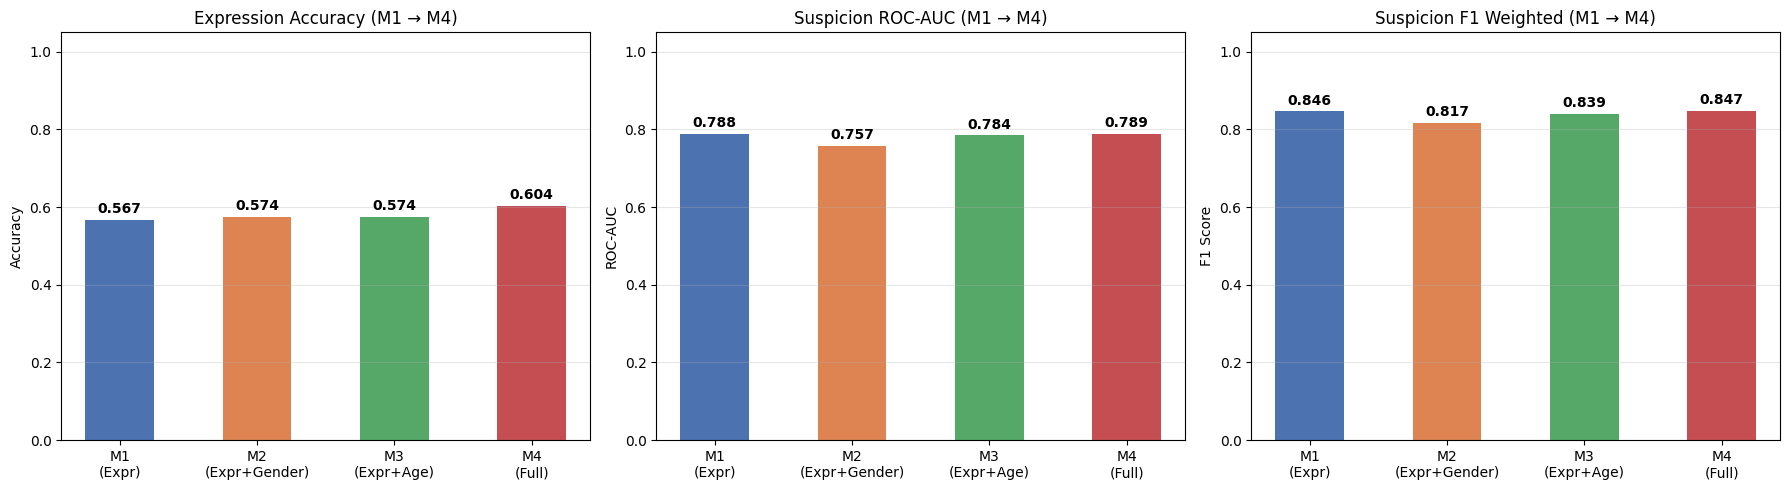

In [38]:

models_labels = ['M1\n(Expr)', 'M2\n(Expr+Gender)', 'M3\n(Expr+Age)', 'M4\n(Full)']
names         = ['M1', 'M2', 'M3', 'M4']
colors        = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

accuracies = [res[m]['expr_accuracy']  for m in names]
susp_aucs  = [res[m]['susp_roc_auc']  for m in names]
susp_f1s   = [res[m]['susp_f1']       for m in names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def bar_chart(ax, values, title, ylabel):
    bars = ax.bar(models_labels, values, color=colors, width=0.5)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{v:.3f}' if not np.isnan(v) else 'N/A',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

bar_chart(axes[0], accuracies, 'Expression Accuracy (M1 → M4)', 'Accuracy')
bar_chart(axes[1], susp_aucs,  'Suspicion ROC-AUC (M1 → M4)',   'ROC-AUC')
bar_chart(axes[2], susp_f1s,   'Suspicion F1 Weighted (M1 → M4)','F1 Score')

plt.tight_layout()
plt.show()


## 17. SUSPICIOUSNESS SCORE DEMO


True Expression : Neutral      | Rule-based suspicion label: 0.123
-----------------------------------------------------------------
  M1: Sad         Susp=0.264 (.)
  M2: Sad         Male     Susp=0.291 (.)
  M3: Sad         Age= 38.2 yrs  Susp=0.316 (.)
  M4: Sad         Age= 33.2 yrs  Male     Susp=0.221 (.)


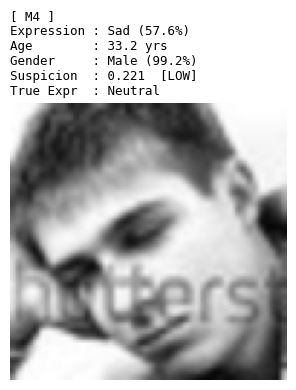


True Expression : Fear         | Rule-based suspicion label: 0.491
-----------------------------------------------------------------
  M1: Fear        Susp=0.433 (~)
  M2: Fear        Male     Susp=0.424 (~)
  M3: Surprise    Age= 56.0 yrs  Susp=0.386 (.)
  M4: Fear        Age= 54.1 yrs  Male     Susp=0.384 (.)


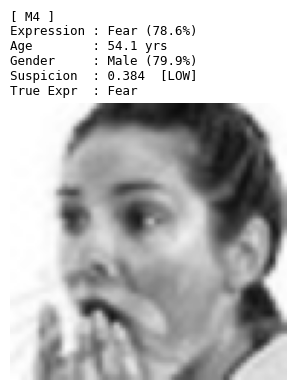


True Expression : Surprise     | Rule-based suspicion label: 0.327
-----------------------------------------------------------------
  M1: Surprise    Susp=0.346 (.)
  M2: Surprise    Male     Susp=0.271 (.)
  M3: Surprise    Age= 11.5 yrs  Susp=0.339 (.)
  M4: Surprise    Age= 15.2 yrs  Male     Susp=0.335 (.)


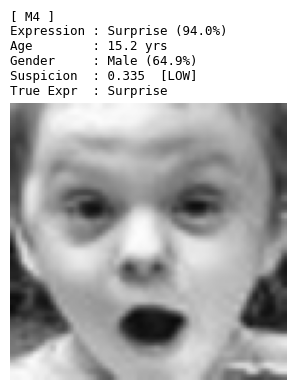

In [39]:

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║   UNIFIED INFERENCE  —  predict_all() + display_prediction()               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

MODEL_OUTPUT_MAP = {
    'M1': {'expr': 0,                          'susp': 1},
    'M2': {'expr': 0, 'gender': 1,             'susp': 2},
    'M3': {'expr': 0, 'age':    1,             'susp': 2},
    'M4': {'expr': 0, 'age':    1, 'gender': 2,'susp': 3},
}

def predict_all(model, image, model_name):
    """
    Full inference pipeline for any model variant (M1–M4).

    image : float32 (H,W,3) in [0,1] already preprocessed
            OR uint8 BGR from cv2.imread / camera frame
    """
    if image.dtype == np.uint8:
        # Apply same CLAHE preprocessing as training for consistency
        gray  = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
        gray  = clahe.apply(gray)
        image = cv2.merge([gray, gray, gray])
        image = cv2.resize(image, TARGET_SIZE).astype(np.float32) / 255.0

    inp  = np.expand_dims(image, axis=0)
    outs = model.predict(inp, verbose=0)
    idx  = MODEL_OUTPUT_MAP[model_name]

    result = {}

    # Expression
    expr_probs = outs[idx['expr']][0]
    result['expression']            = emotion_labels[int(np.argmax(expr_probs))]
    result['expression_confidence'] = float(np.max(expr_probs))
    result['expression_probs']      = {emotion_labels[i]: round(float(expr_probs[i]), 4)
                                        for i in range(7)}
    # Age
    if 'age' in idx:
        result['age'] = round(float(outs[idx['age']][0][0]) * AGE_MAX, 1)

    # Gender
    if 'gender' in idx:
        g = float(outs[idx['gender']][0][0])
        result['gender']            = 'Female' if g > 0.5 else 'Male'
        result['gender_confidence'] = round(float(max(g, 1 - g)), 4)

    # Suspicion
    s = float(outs[idx['susp']][0][0])
    result['suspicion_score'] = round(s, 4)
    result['suspicion_level'] = 'HIGH' if s > 0.6 else ('MEDIUM' if s > 0.4 else 'LOW')

    return result


def display_prediction(model, image, model_name, true_emotion_idx=None):
    r = predict_all(model, image, model_name)
    lines = [f'[ {model_name} ]',
             f'Expression : {r["expression"]} ({r["expression_confidence"]:.1%})']
    if 'age'    in r: lines.append(f'Age        : {r["age"]:.1f} yrs')
    if 'gender' in r: lines.append(f'Gender     : {r["gender"]} ({r["gender_confidence"]:.1%})')
    lines.append(f'Suspicion  : {r["suspicion_score"]:.3f}  [{r["suspicion_level"]}]')
    if true_emotion_idx is not None:
        lines.append(f'True Expr  : {emotion_labels[true_emotion_idx]}')
    plt.figure(figsize=(4, 4))
    plt.imshow(image, cmap='gray' if image.mean(axis=2).std() < 0.01 else None)
    plt.axis('off')
    plt.title('\n'.join(lines), fontsize=9, loc='left', family='monospace')
    plt.tight_layout()
    plt.show()
    return r


# ── Demo: 3 random FER2013 test samples through all four models ───────────────
BEST_MODELS = [('M1', M1_best), ('M2', M2_best), ('M3', M3_best), ('M4', M4_best)]
sample_indices = np.random.choice(len(X_fer_test), 3, replace=False)
true_labels    = np.argmax(y_fer_test, axis=1)

for sample_idx in sample_indices:
    img = X_fer_test[sample_idx]
    tl  = true_labels[sample_idx]

    print(f'\n{"="*65}')
    print(f'True Expression : {emotion_labels[tl]:<12} '
          f'| Rule-based suspicion label: {susp_fer_test[sample_idx]:.3f}')
    print(f'{"-"*65}')

    for mname, mdl in BEST_MODELS:
        r    = predict_all(mdl, img, mname)
        line = f'  {mname}: {r["expression"]:<10}'
        if 'age'    in r: line += f'  Age={r["age"]:5.1f} yrs'
        if 'gender' in r: line += f'  {r["gender"]:<7}'
        level_tag = {'HIGH': '(!)', 'MEDIUM': '(~)', 'LOW': '(.)'}
        line += f'  Susp={r["suspicion_score"]:.3f} {level_tag[r["suspicion_level"]]}'
        print(line)

    display_prediction(M4_best, img, 'M4', tl)


## 18. SAVE ALL MODELS

In [40]:
M1.save('M1_Expression_Only.keras')
M2.save('M2_Expr_Gender.keras')
M3.save('M3_Expr_Age.keras')
M4.save('M4_Full_Model.keras')
print('All 4 models saved.')

All 4 models saved.
